In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
from scipy.fft import fft, fftfreq
import xarray as xr

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Probe_analysis')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# Vertical velocity from PIV analysis
## Made from `/PIV/plate_top_rectangular_IR/...`
* IR: 16 x 32 px
* Overlap = 50%
* SA = 16 x 32 px
* stepsize = 3, 5, 7
* sig2noise threshold = 1.2
* max_iter = 10
* kernel_size = 2

In [3]:
base_path = '/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/'
# Results from PIV processing
# 16 x 32 window size, dt = 3, 5, 7 frames, respectively for the three amplitudes
piv_a03_r1 = xr.open_dataset(base_path + 'f14a03_rec_res_r1.nc')
piv_a03_r2 = xr.open_dataset(base_path + 'f14a03_rec_res_r2.nc')
piv_a03_r3 = xr.open_dataset(base_path + 'f14a03_rec_res_r3.nc')

piv_a02_r1 = xr.open_dataset(base_path + 'f14a02_rec_res_r1.nc')
piv_a02_r2 = xr.open_dataset(base_path + 'f14a02_rec_res_r2.nc')
piv_a02_r3 = xr.open_dataset(base_path + 'f14a02_rec_res_r3.nc')

piv_a01_r1 = xr.open_dataset(base_path + 'f14a01_rec_res_r1.nc')
piv_a01_r2 = xr.open_dataset(base_path + 'f14a01_rec_res_r2.nc')
piv_a01_r3 = xr.open_dataset(base_path + 'f14a01_rec_res_r3.nc')

base_path = '/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/'
# Results from probe analysis
no_plates_20 = pd.read_csv(base_path + 'no_plates_20cm.csv')
plates_20 = pd.read_csv(base_path + 'plates_20cm.csv')

f14a03 = no_plates_20[(no_plates_20["frequency"] == 1.4) & (no_plates_20["volt"] == 0.3)]
f14a02 = no_plates_20[(no_plates_20["frequency"] == 1.4) & (no_plates_20["volt"] == 0.2)]
f14a01 = no_plates_20[(no_plates_20["frequency"] == 1.4) & (no_plates_20["volt"] == 0.1)]

f14a03_p = plates_20[(plates_20["frequency"] == 1.4) & (plates_20["volt"] == 0.3)]
f14a02_p = plates_20[(plates_20["frequency"] == 1.4) & (plates_20["volt"] == 0.2)]
f14a01_p = plates_20[(plates_20["frequency"] == 1.4) & (plates_20["volt"] == 0.1)]

del no_plates_20, plates_20

## The theoretical values
#### Damping coefficient
$\alpha_{theory} = \alpha_{Weber}/(1 + Q)$ 

$Q = \frac{(3 - D/H)gDh^4k^2}{288\nu^2}$ 

$ \alpha_{Weber} = kh^2\omega(D-H)/(24H\nu)$ 

#### Robin parameter
$R_{theory} = (2H\alpha_{theory})/k$

#### Vertical velocity at z = -H

$\operatorname{Re}\{\bar{w}(z=-H)\} = -gh^2(D-H)Ae^{-\alpha x} \frac{\beta}{144\nu^2 + h^4\omega^2}$

where A is the real amplitude of the free surface ($\eta$) and, $\beta = 12\nu(k^2\cos\theta - 2\alpha k\sin\theta) - h^2\omega(k^2\sin\theta + 2\alpha k\cos\theta)$ with the phase $\theta = kx -\omega t$.

In [4]:
start = piv_a03_r1.time.values[0]
end = piv_a03_r1.time.values[-1]
time_piv = piv_a03_r1.time.values

In [5]:
f = 1.4  # frequency (Hz)
omega = 2 * np.pi * f  # angular frequency (rad/s)
g = 9.81  # gravitational acceleration (m/s^2)
nu = 1e-6  # kinematic viscosity of water (m^2/s)
D = 0.2  # water height (m)
H = 0.15  # depth of plate top (m)
h = 0.01  # distance between plates (m)
k = estimate_wavenumber(f, D)

a_theory, a_weber = spatial_damping_coefficient(k, D, H, h)

# Robin parameter
R_theory = robin_parameter(H, a_theory, k)
R_weber = robin_parameter(H, a_weber, k)

In [9]:
A01 = np.mean([np.mean(f14a01['amp_P0']), np.mean(f14a01_p['amp_P0'])])
A02 = np.mean([np.mean(f14a02['amp_P0']), np.mean(f14a02_p['amp_P0'])])
A03 = np.mean([np.mean(f14a03['amp_P0']), np.mean(f14a03_p['amp_P0'])])

In [10]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])

In [19]:
x = 8.06 - x_probe_pos[0]
t = time_piv

# Vertical velocity at z=-H
w_bar_theory_a03 = vertical_velocity(A03, D, H, f, a_theory, k, h, x, t)
w_bar_theory_a02 = vertical_velocity(A02, D, H, f, a_theory, k, h, x, t)
w_bar_theory_a01 = vertical_velocity(A01, D, H, f, a_theory, k, h, x, t)

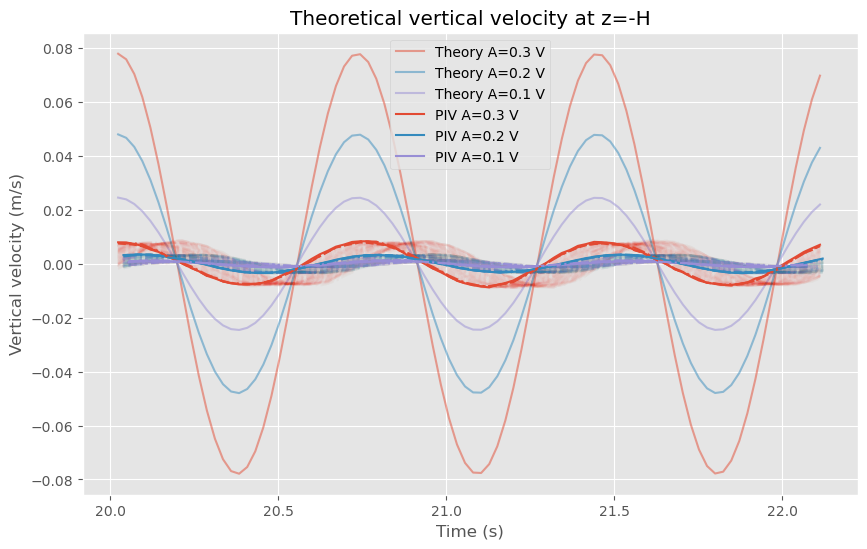

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t, w_bar_theory_a03, color='C0', label='Theory A=0.3 V', alpha=0.5)
ax.plot(t, w_bar_theory_a02, color='C1', label='Theory A=0.2 V', alpha=0.5)
ax.plot(t, w_bar_theory_a01, color='C2', label='Theory A=0.1 V', alpha=0.5)

for idx in range(76):
    ax.plot(piv_a03_r1.time.values, piv_a03_r1['w'][:, 42, idx], color='C0', alpha=0.01)
    ax.plot(piv_a02_r1.time.values, piv_a02_r1['w'][:, 42, idx], color='C1', alpha=0.01)
    ax.plot(piv_a01_r1.time.values, piv_a01_r1['w'][:, 42, idx], color='C2', alpha=0.01)

    ax.plot(piv_a03_r2.time.values, piv_a03_r2['w'][:, 42, idx], color='C0', linestyle='--', alpha=0.01)
    ax.plot(piv_a02_r2.time.values, piv_a02_r2['w'][:, 42, idx], color='C1', linestyle='--', alpha=0.01)
    ax.plot(piv_a01_r2.time.values, piv_a01_r2['w'][:, 42, idx], color='C2', linestyle='--', alpha=0.01)

    ax.plot(piv_a03_r3.time.values, piv_a03_r3['w'][:, 42, idx], color='C0', linestyle='-.', alpha=0.01)
    ax.plot(piv_a02_r3.time.values, piv_a02_r3['w'][:, 42, idx], color='C1', linestyle='-.', alpha=0.01)
    ax.plot(piv_a01_r3.time.values, piv_a01_r3['w'][:, 42, idx], color='C2', linestyle='-.', alpha=0.01)

ax.plot(piv_a03_r1.time.values, piv_a03_r1['w'][:, 42, -1], color='C0', label='PIV A=0.3 V')
ax.plot(piv_a02_r1.time.values, piv_a02_r1['w'][:, 42, -1], color='C1', label='PIV A=0.2 V')
ax.plot(piv_a01_r1.time.values, piv_a01_r1['w'][:, 42, -1], color='C2', label='PIV A=0.1 V')

ax.plot(piv_a03_r2.time.values, piv_a03_r2['w'][:, 42, -1], color='C0', linestyle='--')
ax.plot(piv_a02_r2.time.values, piv_a02_r2['w'][:, 42, -1], color='C1', linestyle='--')
ax.plot(piv_a01_r2.time.values, piv_a01_r2['w'][:, 42, -1], color='C2', linestyle='--')

ax.plot(piv_a03_r3.time.values, piv_a03_r3['w'][:, 42, -1], color='C0', linestyle='-.')
ax.plot(piv_a02_r3.time.values, piv_a02_r3['w'][:, 42, -1], color='C1', linestyle='-.')
ax.plot(piv_a01_r3.time.values, piv_a01_r3['w'][:, 42, -1], color='C2', linestyle='-.')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Vertical velocity (m/s)')
ax.set_title('Theoretical vertical velocity at z=-H')
ax.legend()

In [53]:
base_path = '/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/'
#piv_a03_r1 = xr.open_dataset(base_path + 'f14a03_rec_res_r1.nc')
#piv_a03_r2 = xr.open_dataset(base_path + 'f14a03_rec_res_r2.nc')
piv_a03_r3 = xr.open_dataset(base_path + 'f14a03_rec_res_r3.nc')

#piv_a02_r1 = xr.open_dataset(base_path + 'f14a02_rec_res_r1.nc')
#piv_a02_r2 = xr.open_dataset(base_path + 'f14a02_rec_res_r2.nc')
piv_a02_r3 = xr.open_dataset(base_path + 'f14a02_rec_res_r3.nc')

#piv_a01_r1 = xr.open_dataset(base_path + 'f14a01_rec_res_r1.nc')
#piv_a01_r2 = xr.open_dataset(base_path + 'f14a01_rec_res_r2.nc')
piv_a01_r3 = xr.open_dataset(base_path + 'f14a01_rec_res_r3.nc')

In [54]:
piv_a03_r3

<xarray.Dataset> Size: 14MB
Dimensions:         (time: 88, z: 50, x: 76)
Coordinates:
  * time            (time) float64 704B 20.02 20.05 20.07 ... 22.06 22.09 22.11
  * x               (x) float64 608B 0.002726 0.005452 ... 0.2045 0.2072
  * z               (z) float64 400B 0.001363 0.002726 ... 0.06679 0.06815
Data variables:
    u               (time, z, x) float64 3MB ...
    w               (time, z, x) float64 3MB ...
    vorticity       (time, z, x) float64 3MB ...
    dudx            (time, z, x) float64 3MB ...
    dwdz            (time, z, x) float64 3MB ...
    w_plate_top     (time, x) float64 54kB ...
    dwdz_plate_top  (time, x) float64 54kB ...
    w_top           (time, x) float64 54kB ...
    w_under         (time, x) float64 54kB ...
    dwdz_top        (time, x) float64 54kB ...
    dwdz_under      (time, x) float64 54kB ...
    flag_fraction   (time) float64 704B ...
Attributes:
    description:      PIV results: full velocity fields and values along plat...
    units_u:          m s-1
    units_w:          m s-1
    units_vorticity:  s-1
    units_dudx:       s-1
    units_dwdz:       s-1

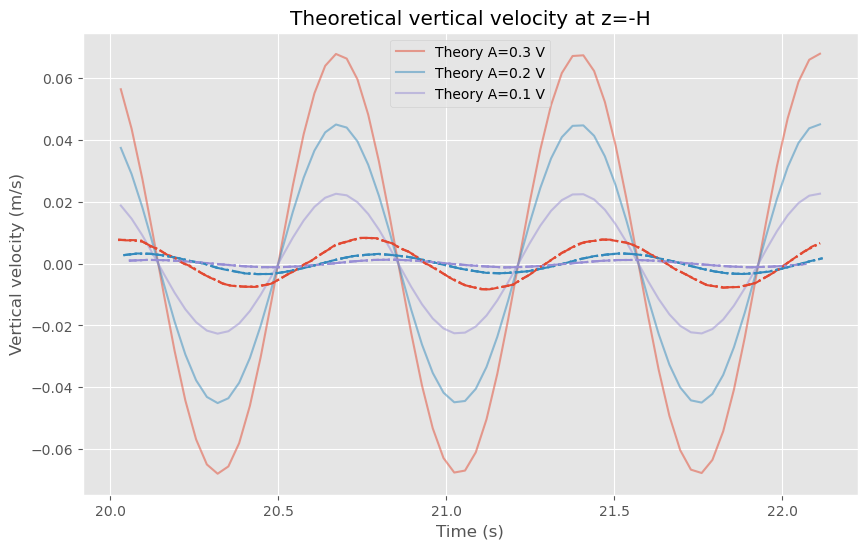

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t, w_bar_theory_a03, color='C0', label='Theory A=0.3 V', alpha=0.5)
ax.plot(t, w_bar_theory_a02, color='C1', label='Theory A=0.2 V', alpha=0.5)
ax.plot(t, w_bar_theory_a01, color='C2', label='Theory A=0.1 V', alpha=0.5)

ax.plot(piv_a03_r3.time.values, piv_a03_r3['w'][:, -1], color='C0', linestyle='-.')
ax.plot(piv_a02_r3.time.values, piv_a02_r3['w'][:, -1], color='C1', linestyle='-.')
ax.plot(piv_a01_r3.time.values, piv_a01_r3['w'][:, -1], color='C2', linestyle='-.')

ax.plot(piv_a03_r3.time.values, piv_a03_r3['w_top'][:, -1], color='C0', linestyle='--')
ax.plot(piv_a02_r3.time.values, piv_a02_r3['w_top'][:, -1], color='C1', linestyle='--')
ax.plot(piv_a01_r3.time.values, piv_a01_r3['w_top'][:, -1], color='C2', linestyle='--')

ax.plot(piv_a03_r3.time.values, piv_a03_r3['w_under'][:, -1], color='C0', linestyle=':')
ax.plot(piv_a02_r3.time.values, piv_a02_r3['w_under'][:, -1], color='C1', linestyle=':')
ax.plot(piv_a01_r3.time.values, piv_a01_r3['w_under'][:, -1], color='C2', linestyle=':')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Vertical velocity (m/s)')
ax.set_title('Theoretical vertical velocity at z=-H')
ax.legend()